In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('mystyle')
import time
import umap
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("Data/bahrain_2023_race_telemetry.csv")
df

,date,driver_number,full_name,name_acronym,team_name,session_key,meeting_key,speed,rpm,n_gear,throttle,brake,drs
0,2023-09-15T09:15:02.731000+00:00,1,Max VERSTAPPEN,VER,Red Bull Racing,9158,1219,0,0,0,0,0,9
1,2023-09-15T09:15:02.971000+00:00,1,Max VERSTAPPEN,VER,Red Bull Racing,9158,1219,0,0,0,0,0,9
2,2023-09-15T09:15:03.211000+00:00,1,Max VERSTAPPEN,VER,Red Bull Racing,9158,1219,0,0,0,0,0,9
3,2023-09-15T09:15:03.491000+00:00,1,Max VERSTAPPEN,VER,Red Bull Racing,9158,1219,0,0,0,0,0,9
4,2023-09-15T09:15:03.771000+00:00,1,Max VERSTAPPEN,VER,Red Bull Racing,9158,1219,0,0,0,0,0,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
360515,2023-09-15T10:37:06.748000+00:00,81,Oscar PIASTRI,PIA,McLaren,9158,1219,0,0,0,0,0,8
360516,2023-09-15T10:37:06.988000+00:00,81,Oscar PIASTRI,PIA,McLaren,9158,1219,0,0,0,0,0,8
360517,2023-09-15T10:37:07.308000+00:00,81,Oscar PIASTRI,PIA,McLaren,9158,1219,0,0,0,0,0,8
360518,2023-09-15T10:37:07.548000+00:00,81,Oscar PIASTRI,PIA,McLaren,9158,1219,0,0,0,0,0,8


In [18]:
np.unique(df['n_gear'])

array([0, 1, 2, 3, 4, 5, 6, 7, 8])

In [3]:
team_names = df['team_name'].unique()
print(team_names)

['Red Bull Racing' 'Williams' 'McLaren' 'Alpine' 'Aston Martin' 'Ferrari'
 'Haas F1 Team' 'AlphaTauri' 'Alfa Romeo' 'Mercedes']


In [4]:
telem = df[['speed', 'rpm', 'throttle']].loc[df['speed'] > 0]
driver_numbers = df['driver_number'].loc[df['speed'] > 0].values
print(np.unique(driver_numbers))

[ 1  2  4 10 11 14 16 18 20 22 23 24 27 31 40 44 55 63 77 81]


In [5]:
telem

,speed,rpm,throttle
3559,1,3238,0
3560,3,3397,0
3561,4,3508,0
3562,5,3610,0
3563,7,3651,0
...,...,...,...
360411,28,4179,0
360412,24,4108,0
360413,12,3816,0
360414,10,4097,0


             speed       rpm  throttle
speed     1.000000  0.838319  0.631753
rpm       0.838319  1.000000  0.689042
throttle  0.631753  0.689042  1.000000


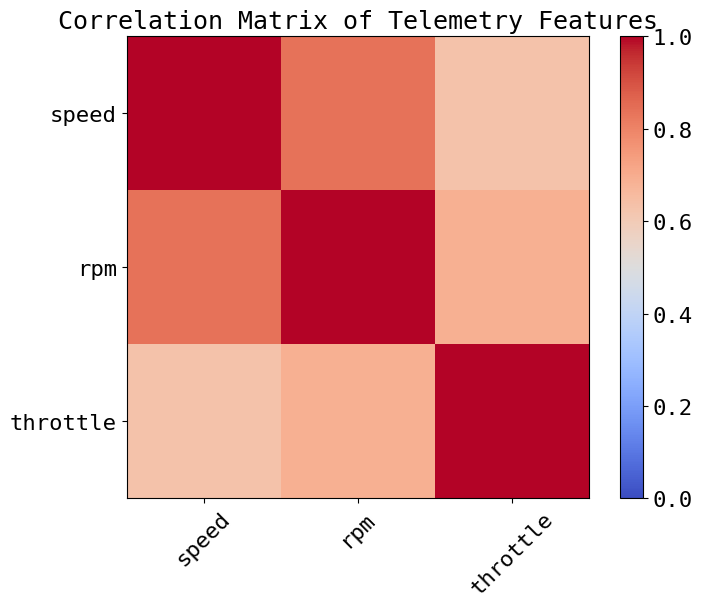

In [6]:
corr = telem.corr()
print(corr)
plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap='coolwarm', vmin=0, vmax=1)
plt.colorbar()
plt.xticks(range(len(telem.columns)), telem.columns, rotation=45)
plt.yticks(range(len(telem.columns)), telem.columns)
plt.title('Correlation Matrix of Telemetry Features');

In [7]:
names = df['name_acronym'].unique()
names

array(['VER', 'SAR', 'NOR', 'GAS', 'PER', 'ALO', 'LEC', 'STR', 'MAG',
       'TSU', 'ALB', 'ZHO', 'HUL', 'OCO', 'LAW', 'HAM', 'SAI', 'RUS',
       'BOT', 'PIA'], dtype=object)

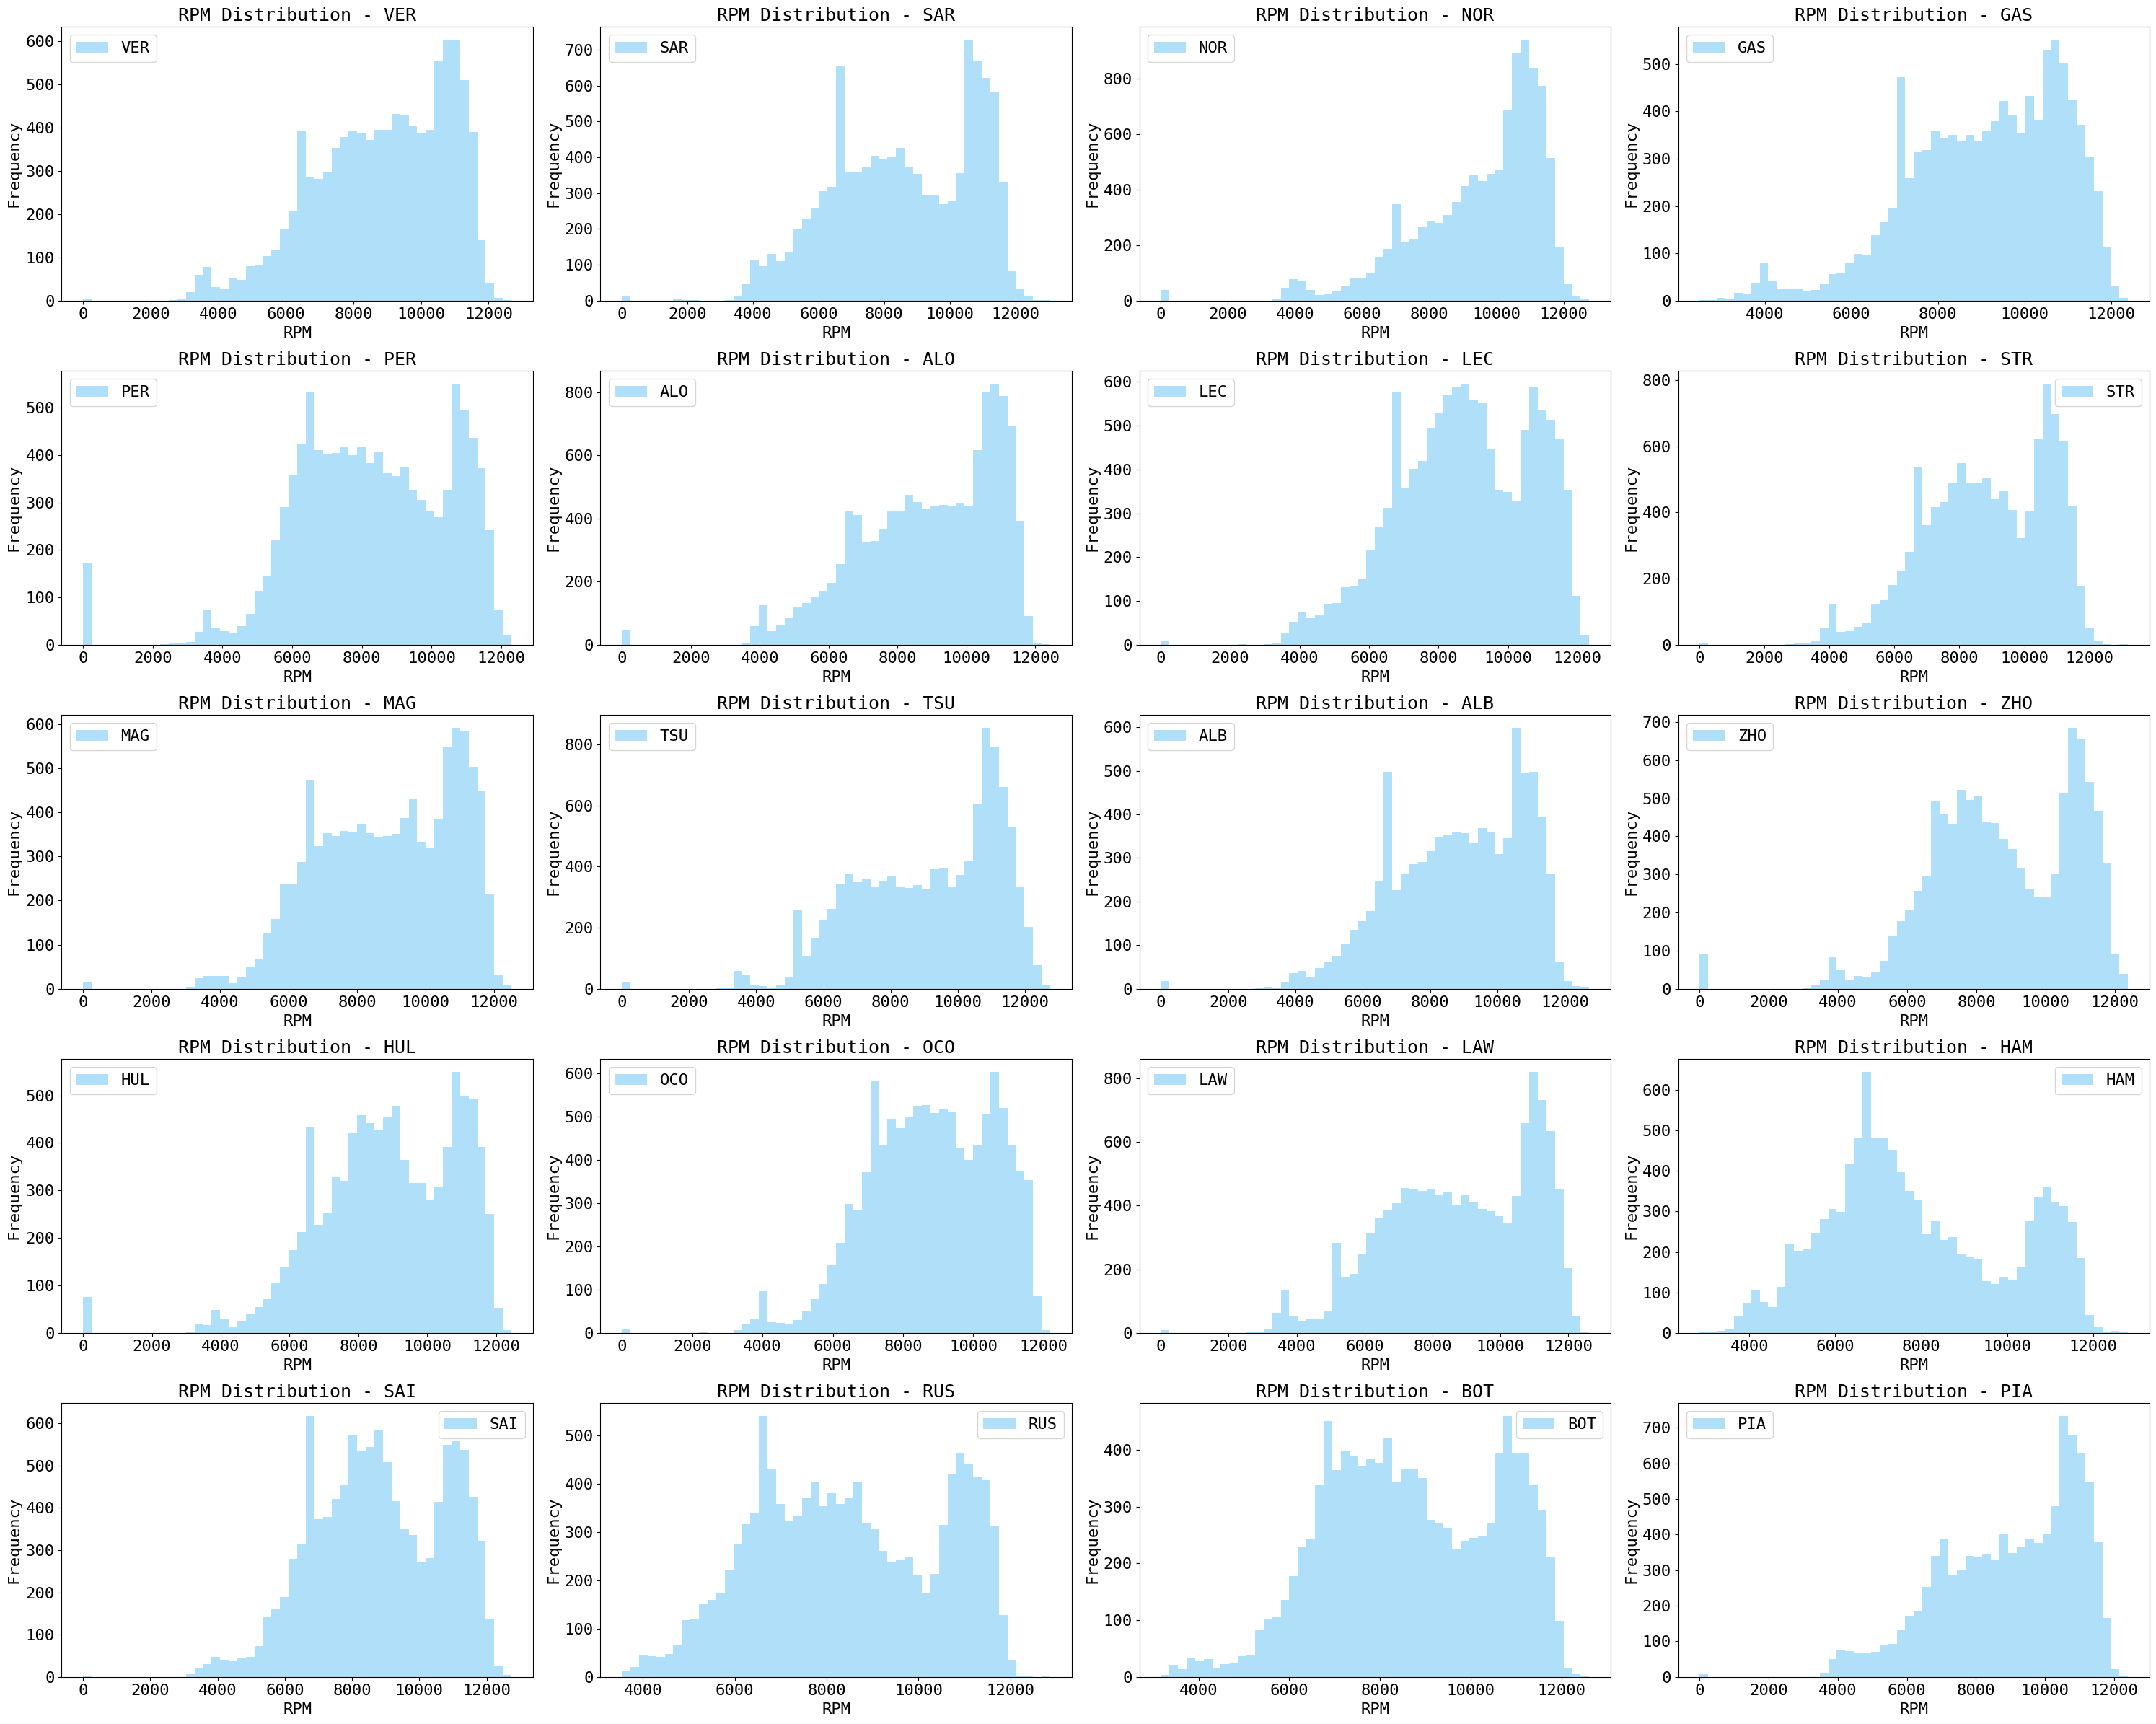

In [8]:
fig, ax = plt.subplots(nrows=5, ncols=4, figsize=(30, 24))
ax = ax.flatten()
for i, name in enumerate(names):
    name_speed = telem['rpm'].loc[df['name_acronym'] == name]
    ax[i].hist(name_speed, bins=50, alpha=0.5, label=name)
    ax[i].set_xlabel('RPM')
    ax[i].set_ylabel('Frequency')
    ax[i].set_title(f'RPM Distribution - {name}')
    ax[i].legend()
plt.tight_layout()

In [9]:
scaler = StandardScaler()
telem_scaled = scaler.fit_transform(telem)

In [10]:
pca = PCA(n_components=2)
y_pcs = pca.fit_transform(telem_scaled)

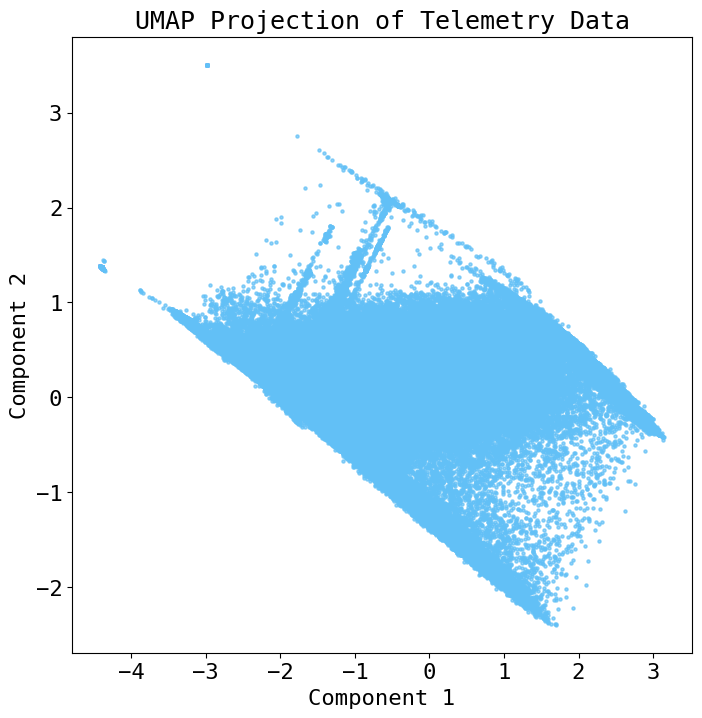

In [11]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')
ax.scatter(y_pcs[:, 0], y_pcs[:, 1], s=5, alpha=0.7)
ax.set_title('UMAP Projection of Telemetry Data');

In [12]:
reducer = umap.UMAP(n_components=2)
y_umap = reducer.fit_transform(telem_scaled)

KeyboardInterrupt: 

In [ ]:
start = time.time()

km = KMeans(
    n_clusters=20,
    init='k-means++',   # smarter initialization than random
    n_init=20,          # run 20 times, keep best — default is only 10
    max_iter=500,       # give it room to converge
    random_state=42
)
km_labels = km.fit_predict(telem_scaled)

end = time.time()

print(f"Time used by K-Means: {(end - start) * 1000:.1f} ms")

Time used by K-Means: 8375.3 ms


In [14]:
uniques = np.unique(driver_numbers, return_counts=True)
# for num, count in zip(*uniques):
#     print(f"Driver {num}: {count} samples")
driver_numbers_seq = driver_numbers.astype(int)
sequence_map = {num: i for i, num in enumerate(np.unique(driver_numbers))}

for i, num in enumerate(driver_numbers):
    driver_numbers_seq[driver_numbers_seq == num] = sequence_map[num]

In [ ]:
driver_numbers_seq

array([ 0,  0,  0, ..., 19, 19, 19])

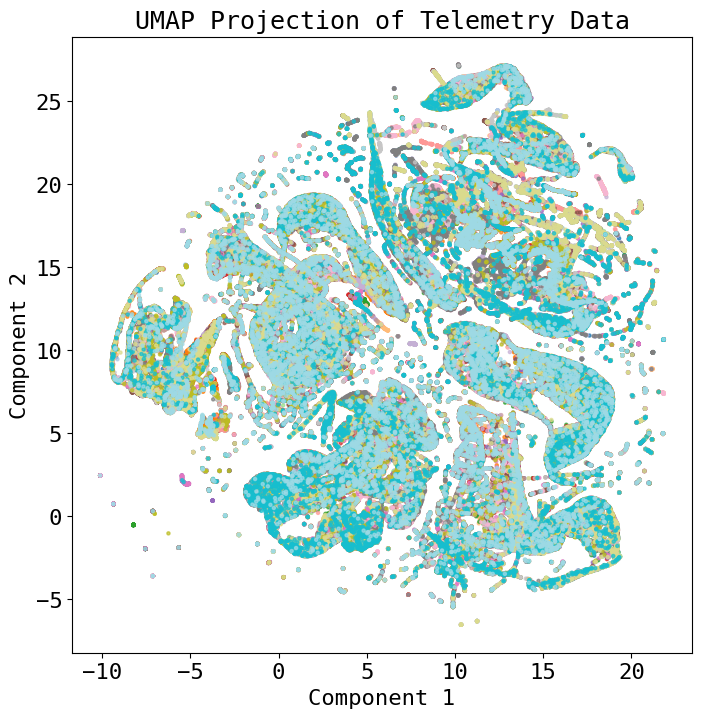

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')
ax.scatter(y_umap[:, 0], y_umap[:, 1], s=5, c=driver_numbers_seq, cmap='tab20', alpha=0.7)
ax.set_title('UMAP Projection of Telemetry Data');

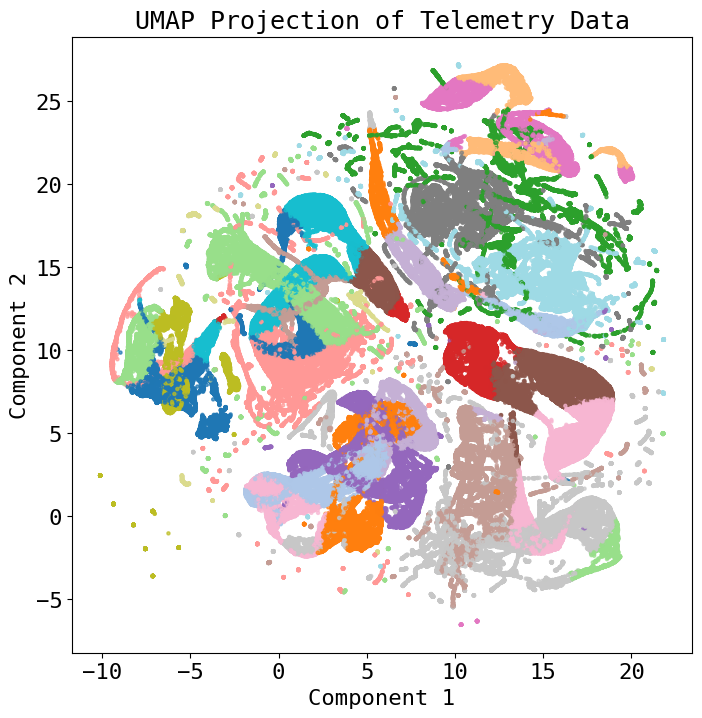

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')
ax.scatter(y_umap[:, 0], y_umap[:, 1], s=5, c=km_labels, cmap='tab20', alpha=0.7)
ax.set_title('UMAP Projection of Telemetry Data');

In [15]:
telem_few = telem[driver_numbers_seq < 2]
telem_few_scaled = scaler.fit_transform(telem_few)

reducer = umap.UMAP(n_components=3)
y_umap_few = reducer.fit_transform(telem_few_scaled)

In [16]:
start = time.time()

km_few = KMeans(
    n_clusters=2,
    init='k-means++',   # smarter initialization than random
    n_init=20,          # run 20 times, keep best — default is only 10
    max_iter=500,       # give it room to converge
    random_state=42
)
km_labels_few = km_few.fit_predict(telem_few_scaled)

end = time.time()

print(f"Time used by K-Means: {(end - start) * 1000:.1f} ms")

Time used by K-Means: 213.4 ms


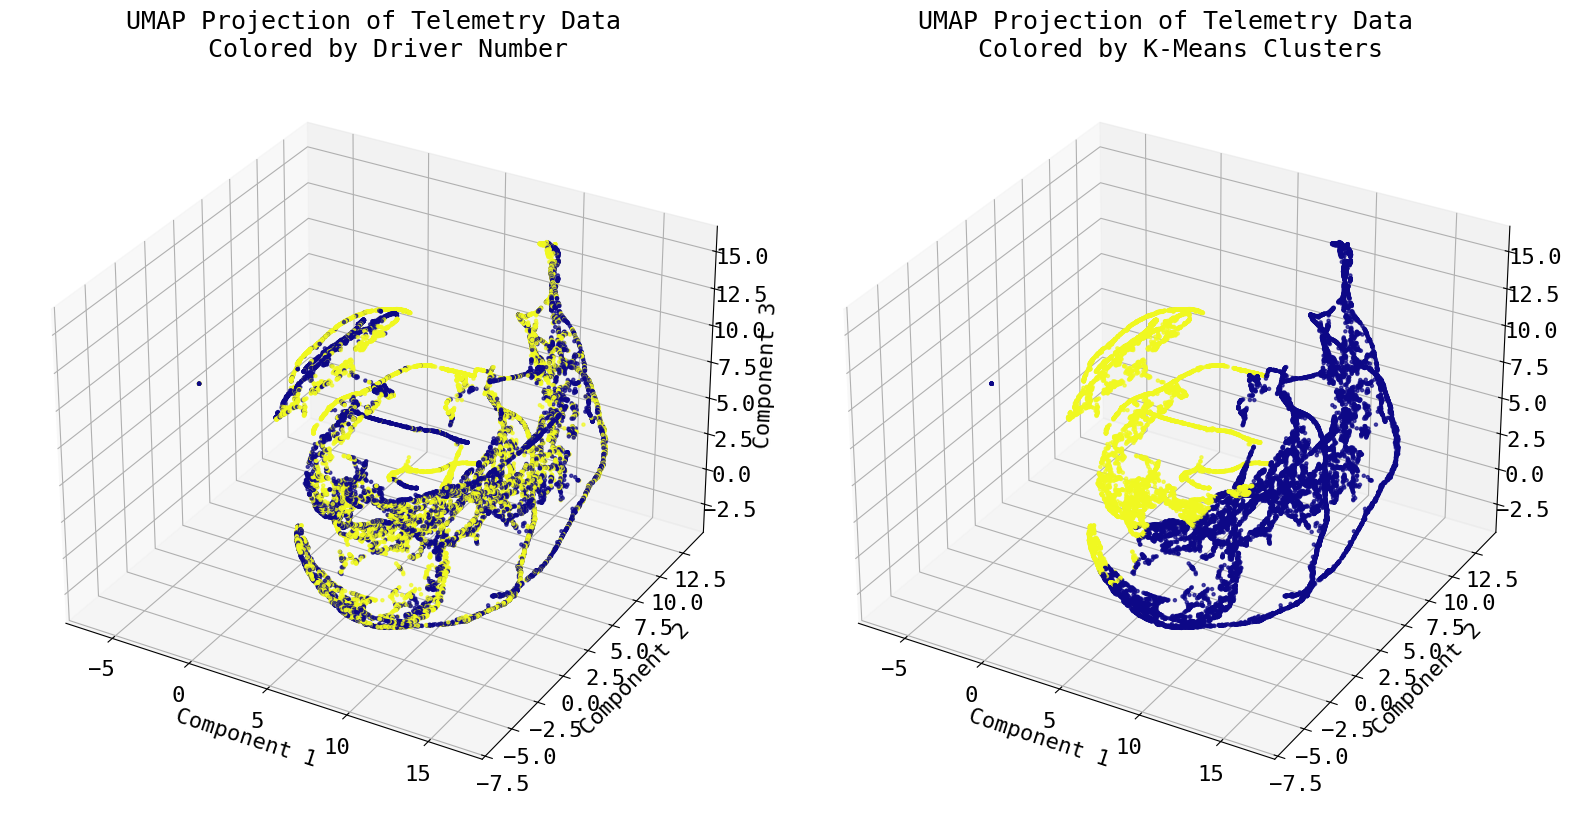

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8), subplot_kw={'projection': '3d'})
ax[0].set_xlabel('Component 1')
ax[0].set_ylabel('Component 2')
ax[0].set_zlabel('Component 3')
ax[0].scatter(y_umap_few[:, 0], y_umap_few[:, 1], y_umap_few[:, 2], s=5, c=driver_numbers_seq[driver_numbers_seq < 2], cmap='plasma', alpha=0.7)
ax[0].set_title('UMAP Projection of Telemetry Data \n Colored by Driver Number')

ax[1].set_xlabel('Component 1')
ax[1].set_ylabel('Component 2')
ax[1].scatter(y_umap_few[:, 0], y_umap_few[:, 1], y_umap_few[:, 2], s=5, c=km_labels_few, cmap='plasma', alpha=0.7)
ax[1].set_title('UMAP Projection of Telemetry Data \n Colored by K-Means Clusters')
plt.tight_layout();